# Crop Disease Forecast — Data Visualization
**Mini Project | DS/AIML-A 2026**

This notebook creates all visualizations for the project — climate trends, disease patterns, correlations, and model results.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
os.makedirs('../outputs/graphs', exist_ok=True)
print('Ready to visualize!')

Ready to visualize!


## 2. Load Processed Data

In [2]:
daily   = pd.read_csv('../dataset/processed_data/climate_cleaned.csv', parse_dates=['date'])
monthly = pd.read_csv('../dataset/processed_data/merged_dataset.csv')

print('Daily data  :', daily.shape)
print('Monthly data:', monthly.shape)

Daily data  : (1461, 15)
Monthly data: (48, 11)


## 3. Chart 1 — Average Monthly Temperature

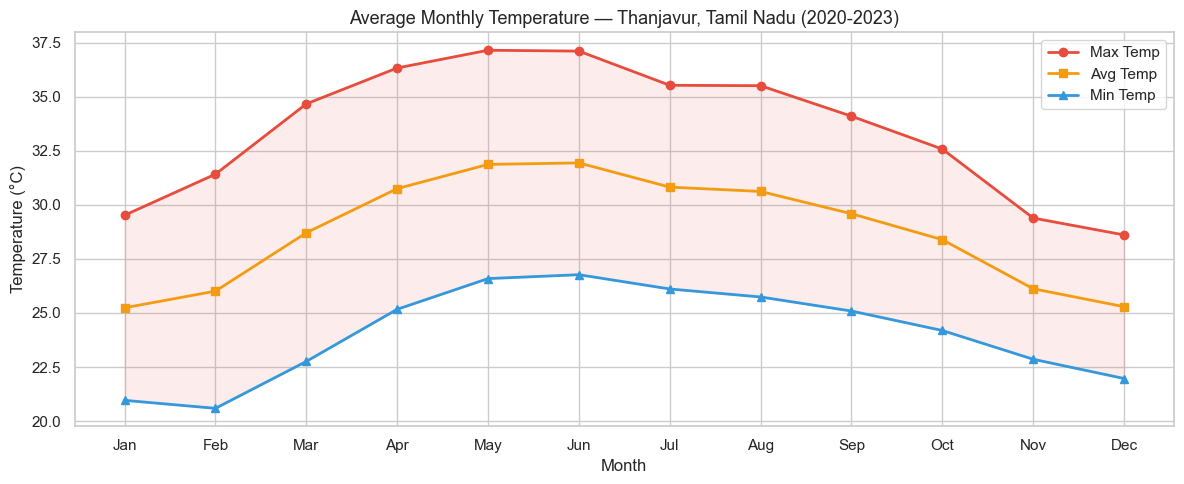

Saved: monthly_temperature.png


In [3]:
monthly_temp = daily.groupby('month')[['temp_max','temp_min','temp_avg']].mean().round(2)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
plt.plot(month_labels, monthly_temp['temp_max'], 'o-', color='#e74c3c', linewidth=2, label='Max Temp')
plt.plot(month_labels, monthly_temp['temp_avg'], 's-', color='#f39c12', linewidth=2, label='Avg Temp')
plt.plot(month_labels, monthly_temp['temp_min'], '^-', color='#3498db', linewidth=2, label='Min Temp')
plt.fill_between(month_labels, monthly_temp['temp_min'], monthly_temp['temp_max'], alpha=0.1, color='#e74c3c')
plt.title('Average Monthly Temperature — Thanjavur, Tamil Nadu (2020-2023)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/graphs/monthly_temperature.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: monthly_temperature.png')

## 4. Chart 2 — Monthly Rainfall

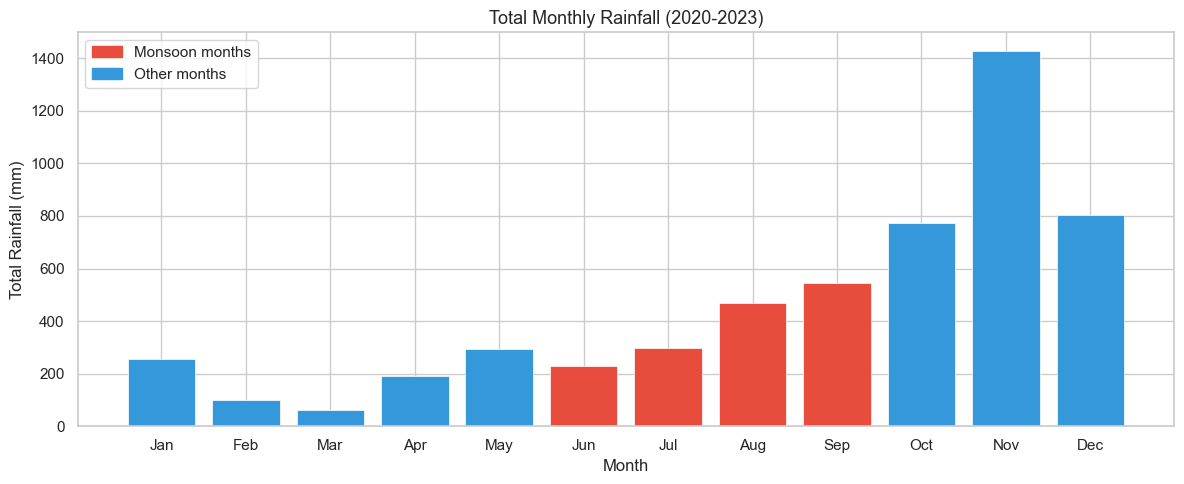

Saved: monthly_rainfall.png


In [4]:
monthly_rain = daily.groupby('month')['rainfall_mm'].sum().round(2)

colors = ['#e74c3c' if m in [6,7,8,9] else '#3498db' for m in range(1,13)]

plt.figure(figsize=(12, 5))
bars = plt.bar(month_labels, monthly_rain.values, color=colors, edgecolor='white', linewidth=0.5)
plt.title('Total Monthly Rainfall (2020-2023)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Total Rainfall (mm)')
monsoon_patch = mpatches.Patch(color='#e74c3c', label='Monsoon months')
normal_patch  = mpatches.Patch(color='#3498db', label='Other months')
plt.legend(handles=[monsoon_patch, normal_patch])
plt.tight_layout()
plt.savefig('../outputs/graphs/monthly_rainfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: monthly_rainfall.png')

## 5. Chart 3 — Humidity vs Disease Outbreaks

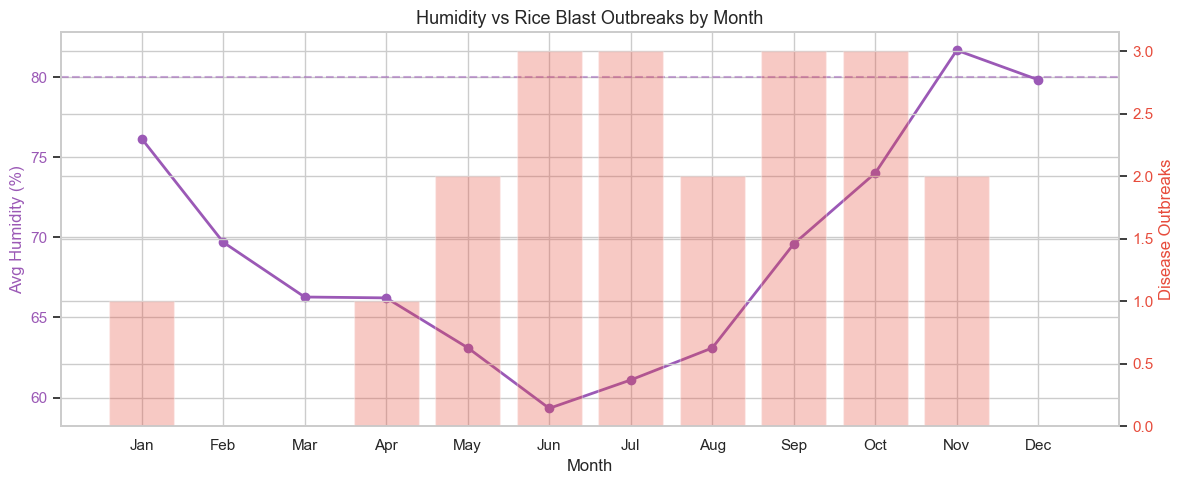

Saved: humidity_vs_disease.png


In [5]:
fig, ax1 = plt.subplots(figsize=(12, 5))

color_hum = '#9b59b6'
ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Humidity (%)', color=color_hum)
ax1.plot(month_labels, monthly['humidity_avg_monthly'].groupby(monthly['month']).mean().values,
         'o-', color=color_hum, linewidth=2, label='Humidity')
ax1.tick_params(axis='y', labelcolor=color_hum)
ax1.axhline(y=80, color=color_hum, linestyle='--', alpha=0.5, label='Risk threshold (80%)')

ax2 = ax1.twinx()
color_dis = '#e74c3c'
ax2.set_ylabel('Disease Outbreaks', color=color_dis)
outbreak_by_month = monthly.groupby('month')['rice_blast'].sum().values
ax2.bar(month_labels, outbreak_by_month, alpha=0.3, color=color_dis, label='Rice Blast')
ax2.tick_params(axis='y', labelcolor=color_dis)

plt.title('Humidity vs Rice Blast Outbreaks by Month', fontsize=13)
fig.tight_layout()
plt.savefig('../outputs/graphs/humidity_vs_disease.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: humidity_vs_disease.png')

## 6. Chart 4 — Correlation Heatmap

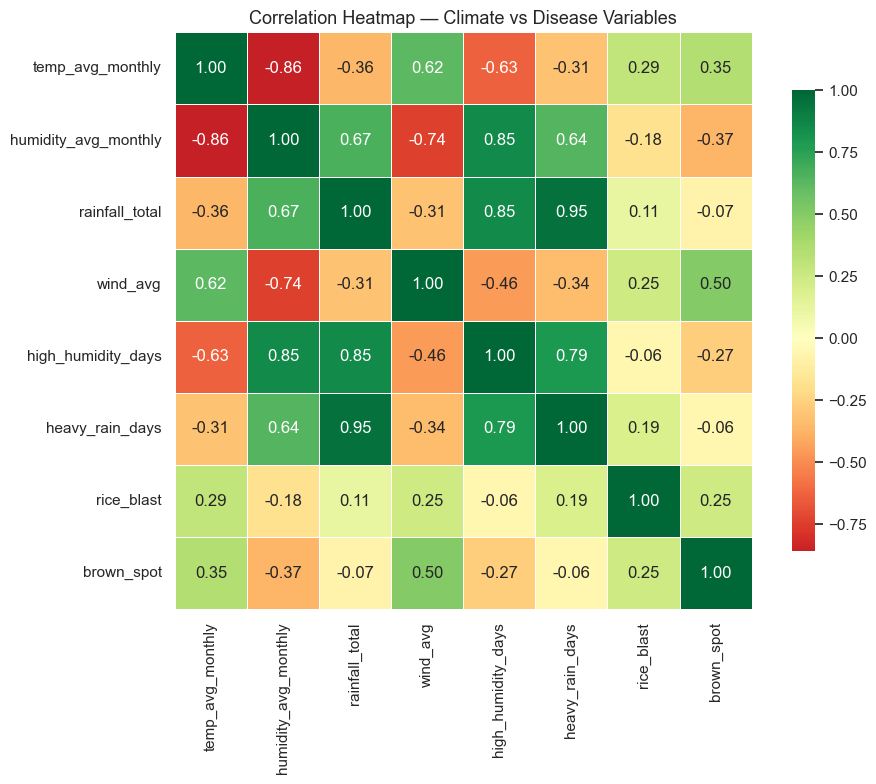

Saved: correlation_heatmap.png


In [6]:
corr_cols = ['temp_avg_monthly','humidity_avg_monthly','rainfall_total',
             'wind_avg','high_humidity_days','heavy_rain_days','rice_blast','brown_spot']

corr_matrix = monthly[corr_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Climate vs Disease Variables', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/graphs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

## 7. Chart 5 — Risk Level by Season

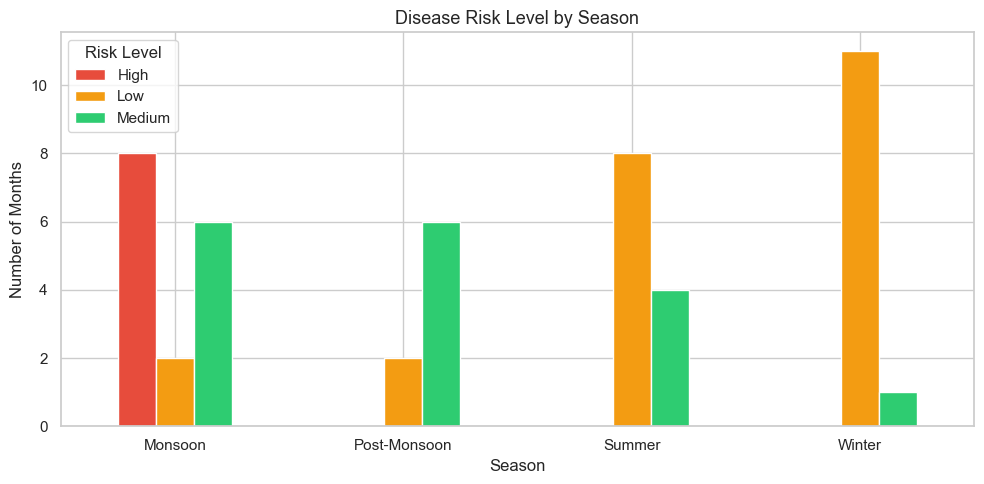

Saved: risk_by_season.png


In [7]:
season_map = {
    6:'Monsoon', 7:'Monsoon', 8:'Monsoon', 9:'Monsoon',
    10:'Post-Monsoon', 11:'Post-Monsoon',
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Summer', 4:'Summer', 5:'Summer'
}
monthly['season'] = monthly['month'].map(season_map)

season_risk = monthly.groupby(['season','risk_level']).size().unstack(fill_value=0)

season_risk.plot(
    kind='bar',
    figsize=(10, 5),
    color=['#e74c3c','#f39c12','#2ecc71'],
    edgecolor='white'
)
plt.title('Disease Risk Level by Season', fontsize=13)
plt.xlabel('Season')
plt.ylabel('Number of Months')
plt.xticks(rotation=0)
plt.legend(title='Risk Level')
plt.tight_layout()
plt.savefig('../outputs/graphs/risk_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: risk_by_season.png')

## 8. Chart 6 — Feature Importance (from Model)

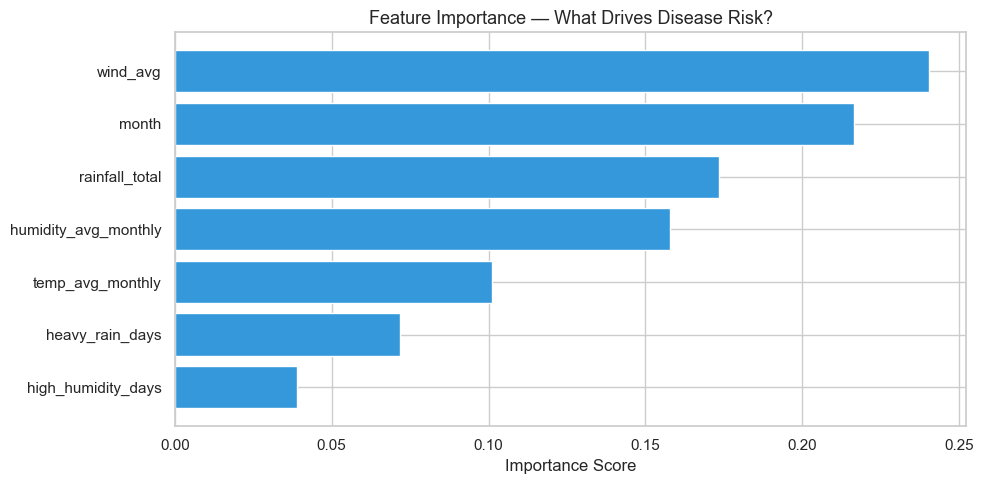

Saved: feature_importance.png


In [8]:
try:
    fi = pd.read_csv('../outputs/results/feature_importance.csv')
    plt.figure(figsize=(10, 5))
    plt.barh(fi['feature'], fi['importance'], color='#3498db', edgecolor='white')
    plt.title('Feature Importance — What Drives Disease Risk?', fontsize=13)
    plt.xlabel('Importance Score')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../outputs/graphs/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: feature_importance.png')
except FileNotFoundError:
    print('Run model.py first to generate feature_importance.csv')

## 9. Summary of All Charts Saved

All graphs are saved in `outputs/graphs/`:
- `disease_distribution.png` — Risk level pie + monthly outbreak bar
- `climate_trends.png` — Temperature, humidity, rainfall over time
- `monthly_temperature.png` — Seasonal temperature pattern
- `monthly_rainfall.png` — Monthly rainfall totals
- `humidity_vs_disease.png` — Humidity vs disease outbreak overlay
- `correlation_heatmap.png` — Climate-disease correlation matrix
- `risk_by_season.png` — Risk level counts by season
- `feature_importance.png` — ML model feature importance